In [1]:
import os
os.environ['XLA_FLAGS'] = os.environ.get('XLA_FLAGS', '') + ' --xla_gpu_autotune_level=0'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'          # don't grab all VRAM upfront
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.80'          # leave 20% free for cuBLAS workspace

import sys, subprocess
print("Kernel Python:", sys.executable)
subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-U",
    "jax[cuda12]",
    "equinox>=0.11", "optax>=0.2",
    "numpy", "pandas", "scikit-learn", "scipy", "matplotlib", "tqdm"],
    check=True)
print("Done installing packages.")


Kernel Python: /usr/bin/python3
Done installing packages.


# 03 — Diffusion Model Training

Load the clustered data, build the `DiffusionTransformer1D`, train with `Trainer`, and inspect generated samples mid-run.

In [ ]:
import importlib
import json
import shutil
import subprocess
import sys
import tempfile
import urllib.request
import zipfile
from pathlib import Path


def clone_repo(repo_url: str, target_dir: Path) -> None:
    result = subprocess.run(
        ['git', 'clone', '--depth', '1', repo_url, str(target_dir)],
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        raise RuntimeError(result.stderr.strip() or result.stdout.strip() or 'git clone failed')


def download_repo_archive(archive_url: str, runtime_dir: Path, repo_dir: Path, extract_dir: Path, archive_path: Path) -> None:
    if archive_path.exists():
        archive_path.unlink()
    if extract_dir.exists():
        shutil.rmtree(extract_dir)
    urllib.request.urlretrieve(archive_url, archive_path)
    with zipfile.ZipFile(archive_path, 'r') as archive:
        archive.extractall(runtime_dir)
        archive.extractall(runtime_dir)
    if repo_dir.exists():
        shutil.rmtree(repo_dir)
    shutil.move(str(extract_dir), str(repo_dir))


def _is_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def find_or_bootstrap_repo_root() -> Path:
    candidates = [
        Path('/home/nicola/Desktop/Supsi/tesina'),
        Path.cwd().resolve(),
        Path('/content/tesina'),
        Path('/tmp/vscode-colab/tesina'),
    ]
    for base in candidates:
        for candidate in [base, *base.parents]:
            if (candidate / 'src').exists() and (candidate / 'data').exists():
                return candidate

    # Choose clone target: prefer /content/ on Colab (persistent within the session
    # and visible in the Colab file browser), otherwise fall back to /tmp.
    if _is_colab():
        runtime_dir = Path('/content')
        repo_dir = runtime_dir / 'tesina'
    else:
        runtime_dir = Path(tempfile.gettempdir()) / 'vscode-colab'
        repo_dir = runtime_dir / 'tesina'

    archive_path = runtime_dir / 'tesina.zip'
    extract_dir = runtime_dir / 'tesina-master'
    repo_url = 'https://github.com/ncapac/tesina.git'
    archive_url = 'https://codeload.github.com/ncapac/tesina/zip/refs/heads/master'

    runtime_dir.mkdir(parents=True, exist_ok=True)
    if repo_dir.exists() and not (repo_dir / 'src').exists():
        shutil.rmtree(repo_dir)

    if not repo_dir.exists():
        try:
            clone_repo(repo_url, repo_dir)
        except Exception:
            download_repo_archive(archive_url, runtime_dir, repo_dir, extract_dir, archive_path)

    if (repo_dir / 'src').exists() and (repo_dir / 'data').exists():
        return repo_dir

    raise RuntimeError('Could not locate or bootstrap the tesina project root from the current notebook kernel.')


REPO_ROOT = find_or_bootstrap_repo_root()
DATA_DIR = REPO_ROOT / 'data'
CHECKPOINT_DIR = REPO_ROOT / 'checkpoints'
RESULTS_DIR = REPO_ROOT / 'results' / 'diffusion'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import equinox as eqx

# Reload src modules so that edits to source files take effect without a kernel restart
import src.data.loader, src.data.dataset, src.models.transformer1d, src.models.diffusion, src.training.train
importlib.reload(src.data.loader)
importlib.reload(src.data.dataset)
importlib.reload(src.models.transformer1d)
importlib.reload(src.models.diffusion)
importlib.reload(src.training.train)

from src.data.loader    import load_raw, compute_stats, normalize, denormalize
from src.data.dataset   import make_windows, train_val_split, numpy_dataloader
from src.models.transformer1d import DiffusionTransformer1D
from src.models.diffusion     import DiffusionProcess
from src.training.train       import Trainer

plt.rcParams['figure.dpi'] = 110
print('Project root:', REPO_ROOT)
print('Results dir :', RESULTS_DIR)
print('JAX devices :', jax.devices())

# ── Training budget ──────────────────────────────────────────────────────────
# BATCH_SIZE increased from 64 → 256 to better utilise T4 VRAM (16 GB).
# LR scaled by sqrt(256/64) = 2× following the sqrt scaling rule for Adam.
# Early stopping (patience=20 epochs) will halt training if val loss plateaus.
QUICK_RUN  = False
N_EPOCHS   = 5    if QUICK_RUN else 200
BATCH_SIZE = 256                   # was 64
LR         = 2e-3                  # was 1e-3; sqrt-scaled for larger batch
WARMUP_STEPS   = 300   if QUICK_RUN else 2000
GUIDANCE_SCALE = 1.5

CHECKPOINT_NAME = 'best_model.pkl'  # loaded if it exists; overwritten when done

Project root: /content/tesina
JAX devices: [CudaDevice(id=0)]


In [ ]:
# ── Google Drive checkpoint persistence (Colab only) ─────────────────────────
# When running on Colab the local runtime is ephemeral.  Mount Drive so that
# checkpoints survive session resets.  Safe to skip on a local kernel.
try:
    import google.colab  # only importable inside Colab
    from google.colab import drive as _drive
    _drive.mount('/content/drive', force_remount=False)
    CHECKPOINT_DIR = Path('/content/drive/MyDrive/tesina_checkpoints')
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR = Path('/content/drive/MyDrive/tesina_results/diffusion')
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    print('Colab: checkpoints →', CHECKPOINT_DIR)
    print('Colab: results     →', RESULTS_DIR)
except (ImportError, Exception) as _e:
    # Not on Colab, or Drive already mounted — keep the default paths set above.
    print('Local kernel: checkpoints →', CHECKPOINT_DIR)
    print('Local kernel: results     →', RESULTS_DIR)

Mounted at /content/drive
Colab: checkpoints will be saved to Google Drive → /content/drive/MyDrive/tesina_checkpoints


## 1. Load & prepare data

In [4]:
df = load_raw(DATA_DIR / 'power.pk')

clusters_df = pd.read_csv(DATA_DIR / 'clusters.csv')
cluster_labels = clusters_df['cluster_id'].values            # (N,)
N_CLUSTERS = int(cluster_labels.max()) + 1

print(f'{df.shape[1]} meters, {N_CLUSTERS} clusters')
print(f'Cluster sizes: { {c: (cluster_labels==c).sum() for c in range(N_CLUSTERS)} }')

# Use the DatetimeIndex already present in power.pk
timestamps = df.index if isinstance(df.index, pd.DatetimeIndex) else None

stats = compute_stats(df, cluster_labels)
df_norm = normalize(df, stats, cluster_labels)


321 meters, 3 clusters
Cluster sizes: {0: np.int64(183), 1: np.int64(34), 2: np.int64(104)}


In [5]:
xs, cs, mid = make_windows(df_norm, cluster_labels, timestamps)
print(f'Windows: xs={xs.shape}  cs={cs.shape}  mid={mid.shape}')

x_train, c_train, x_val, c_val = train_val_split(xs, cs, mid, n_meters=df.shape[1])
print(f'Train: {x_train.shape[0]}  Val: {x_val.shape[0]}')

# ── Per-cluster window count ──
print('\nWindows per cluster (train):')
for cid in range(N_CLUSTERS):
    n_tr = (c_train[:, 0] == cid).sum()
    n_va = (c_val[:,   0] == cid).sum()
    wd   = (c_train[:, 1] == 0).sum()
    we   = (c_train[:, 1] == 1).sum()
    print(f'  Cluster {cid}: train={n_tr:6d}  val={n_va:5d}  (all: weekday={wd}, weekend={we})')

# ── Sanity: check z-score normalisation per cluster ──
print('\nNormalised value stats per cluster (train, should be ~mean=0, std=1):')
for cid in range(N_CLUSTERS):
    mask = c_train[:, 0] == cid
    vals = x_train[mask].ravel()
    print(f'  Cluster {cid}: mean={vals.mean():+.3f}  std={vals.std():.3f}  '
          f'min={vals.min():.3f}  max={vals.max():.3f}')


Windows: xs=(351816, 24)  cs=(351816, 4)  mid=(351816,)
Train: 299208  Val: 52608

Windows per cluster (train):
  Cluster 0: train=169880  val=30688  (all: weekday=213759, weekend=85449)
  Cluster 1: train= 31784  val= 5480  (all: weekday=213759, weekend=85449)
  Cluster 2: train= 97544  val=16440  (all: weekday=213759, weekend=85449)

Normalised value stats per cluster (train, should be ~mean=0, std=1):
  Cluster 0: mean=+0.025  std=1.077  min=-0.306  max=26.476
  Cluster 1: mean=+0.031  std=1.080  min=-0.212  max=17.986
  Cluster 2: mean=+0.024  std=1.066  min=-0.449  max=11.326


## 2. Model & diffusion setup

In [6]:
key = jax.random.PRNGKey(0)

model = DiffusionTransformer1D(
    seq_len     = 24,
    d_model     = 128,
    n_heads     = 4,
    n_layers    = 4,
    d_ff        = 256,
    n_clusters  = N_CLUSTERS,
    n_day_types = 2,
    n_months    = 12,
    n_dow       = 7,
    key         = key,
)

diffusion = DiffusionProcess(T=1000, freq_loss_weight=0.05)

total_steps = N_EPOCHS * max(1, len(x_train) // BATCH_SIZE)
trainer = Trainer(model, diffusion, lr=LR, warmup_steps=WARMUP_STEPS,
                  total_steps=total_steps, checkpoint_dir=str(CHECKPOINT_DIR))

n_params = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array)))
print(f'Model params : {n_params:,}')
print(f'JAX device   : {jax.devices()[0]}')
print(f'Conditioning : c = [cluster_id, day_type, month, dow]  shape=(4,)')


Model params : 846,338
JAX device   : cuda:0
Conditioning : c = [cluster_id, day_type, month, dow]  shape=(4,)


## 3. Training

In [7]:
train_loader = numpy_dataloader(x_train, c_train, batch_size=BATCH_SIZE, shuffle=True,  rng=np.random.default_rng(1))
val_loader   = numpy_dataloader(x_val,   c_val,   batch_size=BATCH_SIZE, shuffle=False, rng=np.random.default_rng(2))

print(f'Training on  : {jax.devices()[0]}')
print(f'Epochs       : {N_EPOCHS}  |  batch size : {BATCH_SIZE}')
print(f'Steps/epoch  : {max(1, len(x_train) // BATCH_SIZE)}')
print(f'Checkpoints  : {CHECKPOINT_DIR}')
print()
print('Starting training — first step triggers JAX JIT compilation (~3-5 min on GPU), then steps are fast.')

trainer.fit(
    train_loader    = train_loader,
    val_loader      = val_loader,
    n_epochs        = N_EPOCHS,
    val_every       = 1,
    save_every      = max(1, N_EPOCHS // 5),
    log_every_steps = max(1, len(x_train) // BATCH_SIZE // 4),
    val_batches     = max(1, len(x_val) // BATCH_SIZE)
)
train_losses = trainer.train_losses
val_losses   = trainer.val_losses
print(f'\nTraining complete. Final train loss: {train_losses[-1]:.4f}  val loss: {val_losses[-1]:.4f}')


Training on  : cuda:0
Epochs       : 200  |  batch size : 256
Steps/epoch  : 1168
Checkpoints  : /content/drive/MyDrive/tesina_checkpoints

Starting training — first step triggers JAX JIT compilation (~3-5 min on GPU), then steps are fast.
  step    292  loss 0.1593
  step    584  loss 0.1051
  step    876  loss 0.0792
  step   1168  loss 0.0993
Epoch   1/200  train_loss 0.3299  val_loss 0.0870  [395.6s]  [C0=0.3058  C1=0.3071  C2=0.3418]
  ✓ checkpoint saved → /content/drive/MyDrive/tesina_checkpoints/best_model.pkl
  step   1460  loss 0.1290
  step   1752  loss 0.0895
  step   2044  loss 0.0849
  step   2336  loss 0.0945
Epoch   2/200  train_loss 0.0939  val_loss 0.0764  [59.7s]  [C0=0.0810  C1=0.0742  C2=0.1174]
  ✓ checkpoint saved → /content/drive/MyDrive/tesina_checkpoints/best_model.pkl
  step   2628  loss 0.0925
  step   2920  loss 0.0875
  step   3212  loss 0.0892
  step   3504  loss 0.0937
Epoch   3/200  train_loss 0.0857  val_loss 0.0691  [46.2s]  [C0=0.0733  C1=0.0650  C2=0

In [8]:
# ── Download checkpoint to local machine (Colab only) ────────────────────────
try:
    from google.colab import files as _colab_files
    _ckpt_path = CHECKPOINT_DIR / CHECKPOINT_NAME
    if _ckpt_path.exists():
        print(f'Downloading {_ckpt_path.name} ...')
        _colab_files.download(str(_ckpt_path))
    else:
        print(f'Checkpoint not found at {_ckpt_path} — run training first.')
except ImportError:
    print('Not on Colab — checkpoint is already local at', CHECKPOINT_DIR / CHECKPOINT_NAME)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4. Loss curves

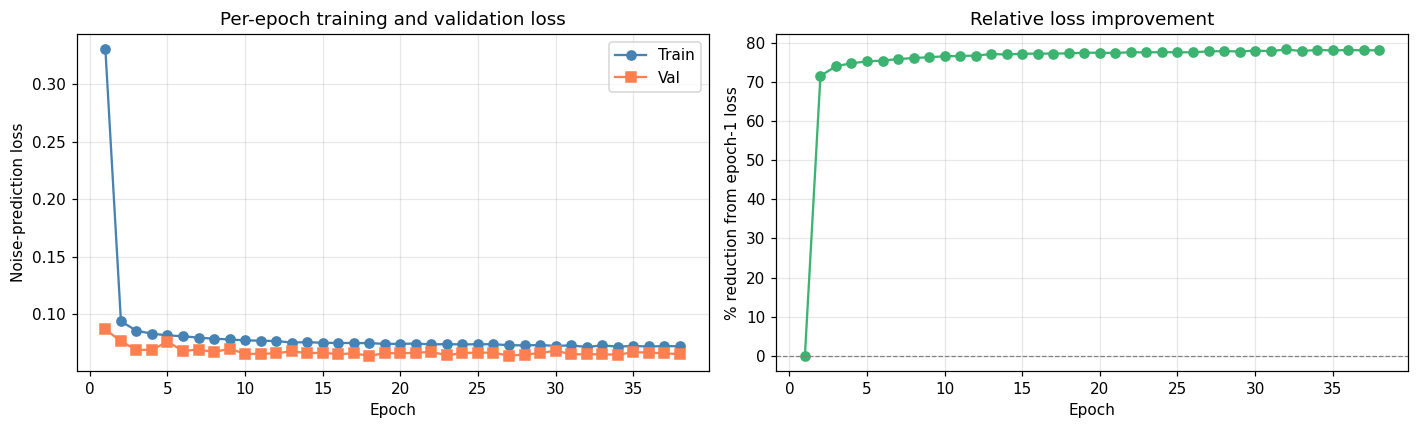

Epoch 1 loss: 0.3299
Final  loss : 0.0722  (78.1% reduction)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs = range(1, len(train_losses) + 1)
axes[0].plot(list(epochs), train_losses, 'o-', color='steelblue', linewidth=1.5, label='Train')
axes[0].plot(list(epochs), val_losses,   's-', color='coral',     linewidth=1.5, label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Noise-prediction loss')
axes[0].set_title('Per-epoch training and validation loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Relative improvement curve (useful for detecting convergence)
if len(train_losses) > 1:
    rel_improvement = [(train_losses[0] - l) / train_losses[0] * 100 for l in train_losses]
    axes[1].plot(list(epochs), rel_improvement, 'o-', color='mediumseagreen', linewidth=1.5)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('% reduction from epoch-1 loss')
    axes[1].set_title('Relative loss improvement')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(0, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'loss_curves.png', dpi=150, bbox_inches='tight')
print(f'Saved → {RESULTS_DIR / "loss_curves.png"}')
plt.show()
print(f'Epoch 1 loss: {train_losses[0]:.4f}')
print(f'Final  loss : {train_losses[-1]:.4f}  ({(train_losses[0]-train_losses[-1])/train_losses[0]*100:.1f}% reduction)')
if QUICK_RUN:
    print('\n⚠ QUICK_RUN=True: only 5 epochs trained. For thesis-quality results,')
    print('  set QUICK_RUN=False and run on GPU (~200 epochs, several hours).')

## 5. Quick sample inspection (DDIM 50 steps)

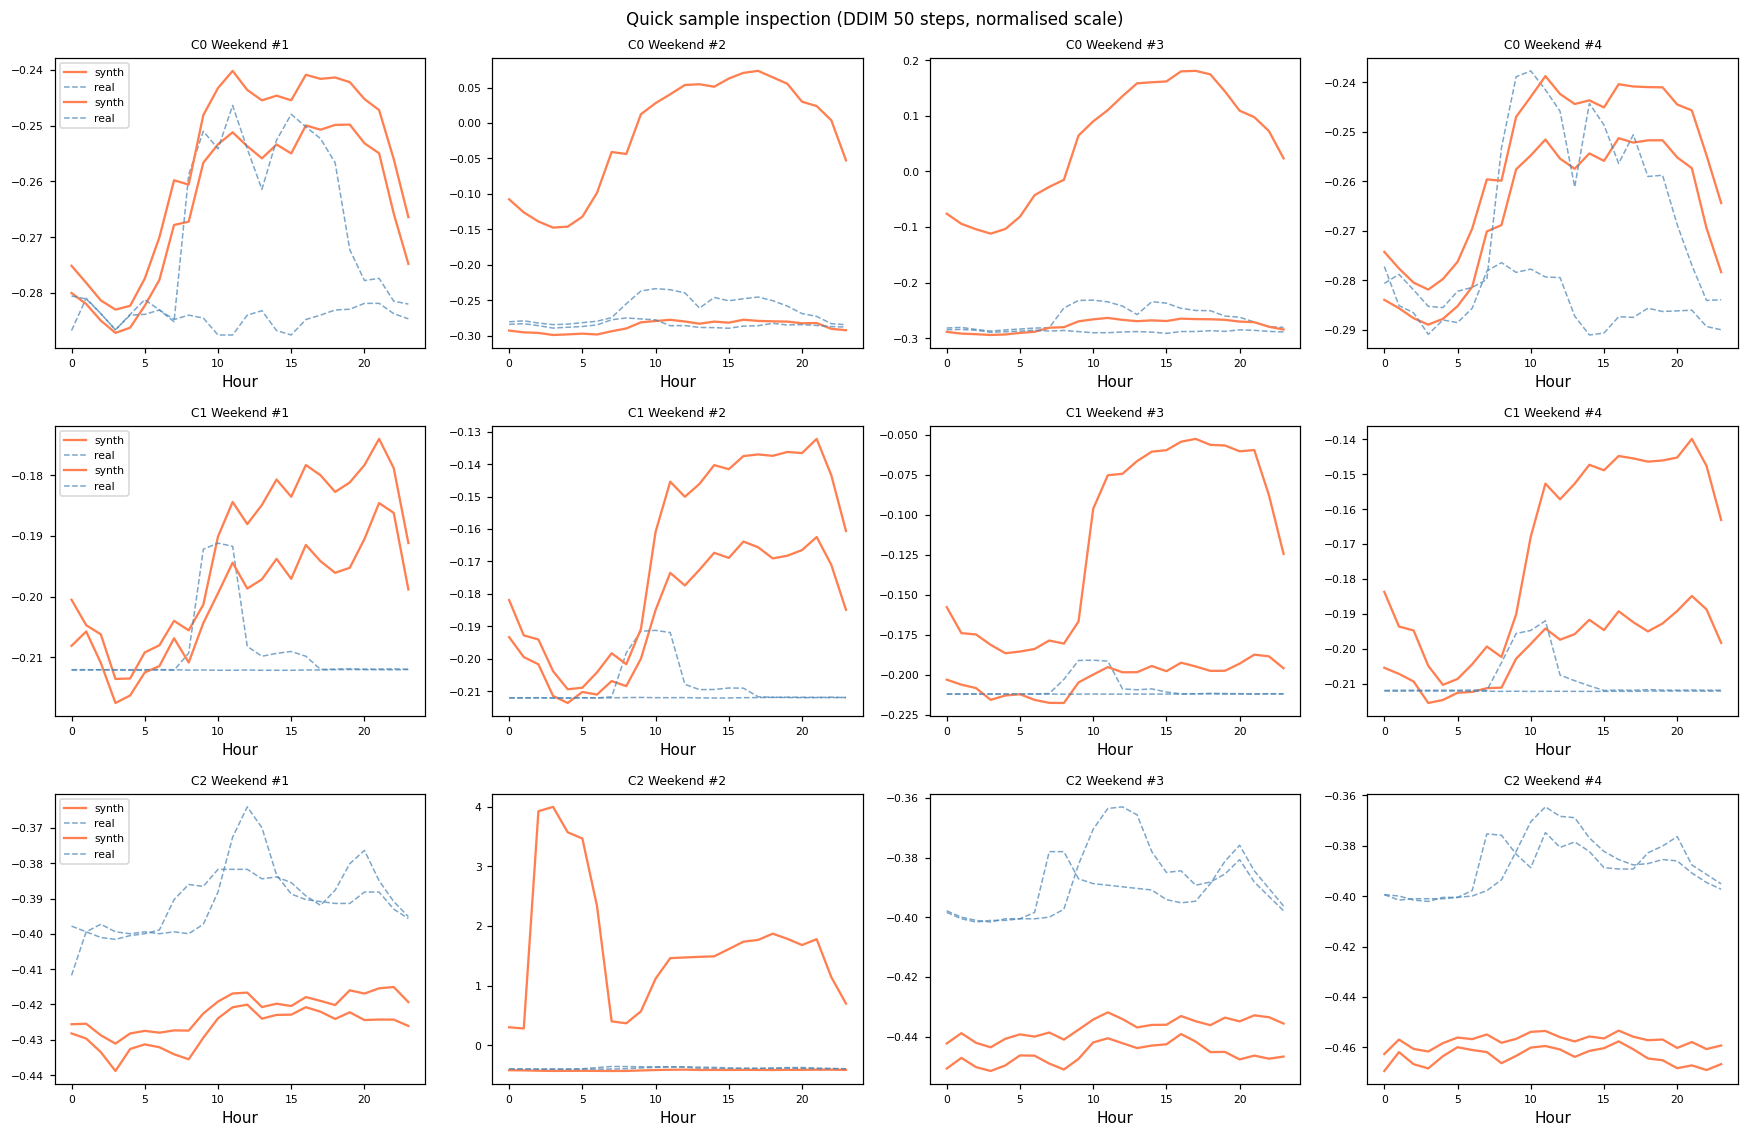

In [ ]:

hours  = np.arange(24)
n_show = 4

fig, axes = plt.subplots(N_CLUSTERS, 4, figsize=(16, 3.5 * N_CLUSTERS))
day_labels = ['Weekday', 'Weekend']

for cid in range(N_CLUSTERS):
    for dt in range(2):
        # month=5 (June), dow=1 (Tue) for weekday, dow=5 (Sat) for weekend
        rep_dow = 1 if dt == 0 else 5
        c_batch  = jnp.array([[cid, dt, 5, rep_dow]] * n_show, dtype=jnp.int32)
        gen_key  = jax.random.PRNGKey(cid * 10 + dt)
        samples_norm = diffusion.ddim_sample(
            trainer.model, c_batch,
            seq_len=24, batch_size=n_show,
            key=gen_key, n_steps=50, guidance_scale=GUIDANCE_SCALE
        )  # (n_show, 24) — normalised
        samples_norm = np.array(samples_norm)

        real_mask = (c_train[:, 0] == cid) & (c_train[:, 1] == dt)
        real_sample = x_train[real_mask][:n_show] if real_mask.sum() > 0 else None

        for k in range(n_show):
            ax = axes[cid, k] if N_CLUSTERS > 1 else axes[k]
            ax.plot(hours, samples_norm[k], color='coral', linewidth=1.5, label='synth')
            if real_sample is not None and k < len(real_sample):
                ax.plot(hours, real_sample[k], color='steelblue', linewidth=1,
                        linestyle='--', alpha=0.7, label='real')
            title_sfx = day_labels[dt]
            ax.set_title(f'C{cid} {title_sfx} #{k+1}', fontsize=8)
            ax.set_xlabel('Hour'); ax.tick_params(labelsize=7)
            if k == 0: ax.legend(fontsize=7)

plt.suptitle('Quick sample inspection (DDIM 50 steps, normalised scale)', fontsize=11)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'sample_inspection.png', dpi=150, bbox_inches='tight')
print(f'Saved → {RESULTS_DIR / "sample_inspection.png"}')
plt.show()

## 6. Save final checkpoint

In [11]:

trainer.save(CHECKPOINT_NAME)

n_params = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(trainer.model, eqx.is_array)))
print(f"  Parameters : {n_params:,}")
print(f"  Epochs done: {N_EPOCHS}  (QUICK_RUN={QUICK_RUN})")
if trainer.val_losses:
    print(f"  Best val   : {min(trainer.val_losses):.4f}  (epoch {np.argmin(trainer.val_losses)+1})")


  ✓ checkpoint saved → /content/drive/MyDrive/tesina_checkpoints/best_model.pkl
  Parameters : 846,338
  Epochs done: 200  (QUICK_RUN=False)
  Best val   : 0.0639  (epoch 18)


## 7. Observations


In [ ]:

# ── §7 Training observations ─────────────────────────────────────────────────

print("=" * 60)
print("TRAINING RUN SUMMARY")
print("=" * 60)

print(f"\n  Epochs        : {N_EPOCHS}  (QUICK_RUN={QUICK_RUN})")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Learning rate : {LR}  (cosine schedule, warmup={WARMUP_STEPS})")
print(f"  Steps/epoch   : {max(1, len(x_train) // BATCH_SIZE)}")
print(f"  Model params  : {sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(trainer.model, eqx.is_array))):,}")

summary = {
    "epochs": N_EPOCHS,
    "quick_run": QUICK_RUN,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "warmup_steps": WARMUP_STEPS,
    "guidance_scale": GUIDANCE_SCALE,
    "n_clusters": N_CLUSTERS,
    "model_params": int(sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(trainer.model, eqx.is_array)))),
    "device": str(jax.devices()[0]),
    "train_losses": trainer.train_losses,
    "val_losses": trainer.val_losses,
}

if trainer.train_losses:
    first, last = trainer.train_losses[0], trainer.train_losses[-1]
    pct = (first - last) / first * 100
    print(f"\n  Initial loss  : {first:.4f}")
    print(f"  Final loss    : {last:.4f}  ({pct:.1f}% reduction)")
    best_epoch = int(np.argmin(trainer.val_losses)) + 1 if trainer.val_losses else "—"
    best_val   = min(trainer.val_losses)               if trainer.val_losses else float('nan')
    print(f"  Best val loss : {best_val:.4f}  (epoch {best_epoch})")
    summary["initial_loss"] = first
    summary["final_loss"] = last
    summary["loss_reduction_pct"] = round(pct, 2)
    summary["best_val_loss"] = best_val
    summary["best_val_epoch"] = best_epoch

print(f"\n  Training device: {jax.devices()[0]}")

# ── Save training summary to disk ───────────────────────────────────────────
summary_path = RESULTS_DIR / 'training_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"\n  Results saved to {RESULTS_DIR}/")
print(f"    - training_summary.json")
print(f"    - loss_curves.png")
print(f"    - sample_inspection.png")

print(f"\n  Next step: run 04_evaluation.ipynb after full training on GPU (~200 epochs).")
print("  Expected full-training metric targets:")
print("    Discriminative accuracy ≤ 0.55  (good sample quality)")
print("    ACF L2 distance         ≤ 0.05  (temporal structure preserved)")

TRAINING RUN SUMMARY

  Epochs        : 200  (QUICK_RUN=False)
  Batch size    : 256
  Learning rate : 0.002  (cosine schedule, warmup=2000)
  Steps/epoch   : 1168
  Model params  : 846,338

  Initial loss  : 0.3299
  Final loss    : 0.0722  (78.1% reduction)
  Best val loss : 0.0639  (epoch 18)

  Training device: cuda:0

  Next step: run 04_evaluation.ipynb after full training on GPU (~200 epochs).
  Expected full-training metric targets:
    Discriminative accuracy ≤ 0.55  (good sample quality)
    ACF L2 distance         ≤ 0.05  (temporal structure preserved)
